# BrushCue Example: Zoom Blur

<a href="https://colab.research.google.com/github/ditotechnologies/monorepo/blob/main/py/brushcue/examples/zoom_blur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/zoom-blur

In [ ]:
!pip install brushcue

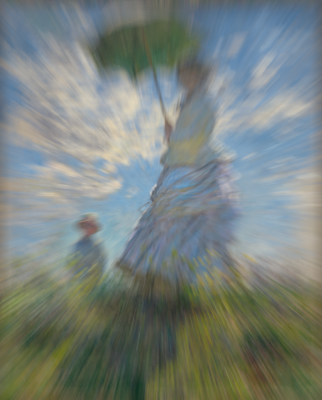

In [1]:
import brushcue
from PIL import Image
import io

input_image_1 = brushcue.composition_monet_women_with_parasol() # insert your own image here
string_constant_2 = brushcue.string_constant("    let image_size = textureDimensions(input_texture);\n    let center_pixel = center * vec2<f32>(image_size);\n    let uv = vec2<f32>(position);\n    let dir = normalize(uv - center_pixel);\n    let dist = distance(uv, center_pixel);\n    \n    var result = vec4<f32>(0.0);\n    let samples = 16;\n    \n    for (var i = 0; i < samples; i++) {\n        let offset = -1.0 + (f32(i) / f32(samples)) * 2.0;\n        let sample_x = i32(uv.x + dir.x * dist * offset * strength);\n        let sample_y = i32(uv.y + dir.y * dist * offset * strength);\n        let sample_pos = vec2<i32>(sample_x, sample_y);\n        result += textureLoad(input_texture, sample_pos, 0);\n    }\n    \n    return result / f32(samples);")
string_constant_3 = brushcue.string_constant("// Zoom blur helper - center is normalized (0.5, 0.5 is image center)")
composition_color_profile_4 = brushcue.composition_color_profile(input_image_1)
bool_constant_5 = brushcue.bool_constant(True)
string_constant_6 = brushcue.string_constant("strength")
dictionary_create_7 = brushcue.dictionary_create()
string_constant_8 = brushcue.string_constant("center")
float_constant_9 = brushcue.float_constant(0.07000000029802322)
float_constant_10 = brushcue.float_constant(0.5)
float_constant_11 = brushcue.float_constant(0.5)
strength_12 = brushcue.float_passthrough(float_constant_9)
vector_2_float_from_components_13 = brushcue.vector2f_from_components(float_constant_10, float_constant_11)
center_14 = brushcue.vector2f_passthrough(vector_2_float_from_components_13)
vector_2_float_add_to_dictionary_15 = brushcue.vector2f_add_to_dictionary(dictionary_create_7, string_constant_8, center_14)
float_add_to_dictionary_16 = brushcue.float_add_to_dictionary(vector_2_float_add_to_dictionary_15, string_constant_6, strength_12)
zoom_blur_shader_17 = brushcue.composition_custom_transformer_shader(input_image_1, string_constant_2, string_constant_3, composition_color_profile_4, composition_color_profile_4, float_add_to_dictionary_16, bool_constant_5)

ctx = brushcue.Context()
result = zoom_blur_shader_17.execute(ctx)
composition = result.as_composition()
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400)) # remove this line for full resolution
img
